# Dim Reduction e Clustering su Lesioni (Quick Test)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering

if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

from src.analysis.distances import binary_pairwise_distance

%matplotlib inline

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Caricamento Matrice
matrix_path = Path('../data/derived/lesion_matrix/21-07_s1.1/matrix.npy')
X = np.load(matrix_path)
print(f"Shape della matrice: {X.shape}")

Shape della matrice: (1150, 254865)


In [3]:
# Carica Metadata e calcola Volume Lesionale in Voxel
metadata_path = Path('../data/derived/lesion_matrix/21-07_s1.1/metadata.csv')
metadata = pd.read_csv(metadata_path)
metadata['volume_voxel'] = X.sum(axis=1)

clinical_meta_path = Path('../assets/metadata/UNIPD_WashU_participants_lesions.tsv')
clinical_meta = pd.read_csv(clinical_meta_path, sep='\t')
metadata = metadata.merge(clinical_meta, left_on='subject_id', right_on='participant_id', how='left')

print("Metadata caricati con successo!")

Metadata caricati con successo!


In [4]:
# Calcolo Distanze (necessario per jaccard, dice)
metric = "jaccard" # Scegli tra: "euclidean", "jaccard", "dice"

if metric in ["jaccard", "dice"]:
    print(f"Precalcolo matrice di distanza per metrica: {metric}")
    X_dist = binary_pairwise_distance(X, metric)
else:
    X_dist = X
    print("Nessun precalcolo della distanza richiesto")

Precalcolo matrice di distanza per metrica: jaccard


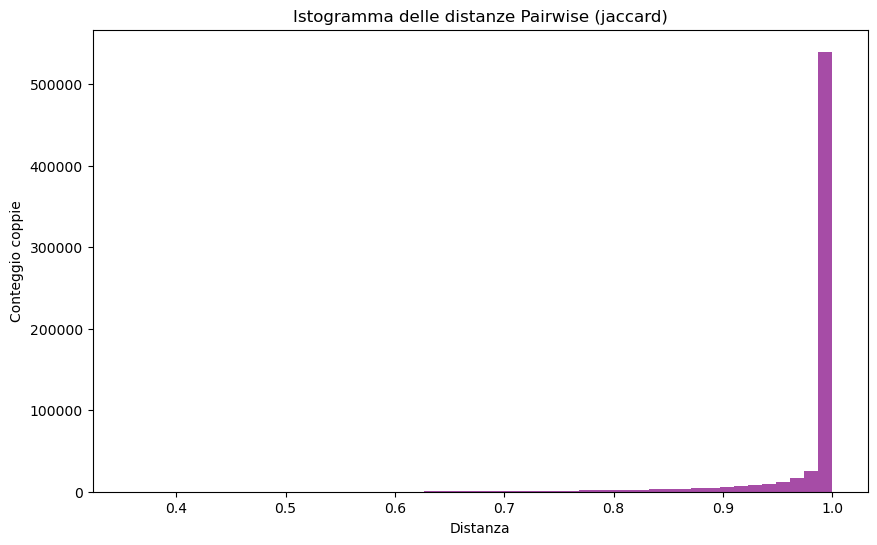

In [5]:
# Plot: Istogramma delle distanze
if metric in ['jaccard', 'dice']:
    plt.figure(figsize=(10, 6))
    dist_triu = X_dist[np.triu_indices_from(X_dist, k=1)]
    plt.hist(dist_triu, bins=50, color='purple', alpha=0.7)
    plt.title(f"Istogramma delle distanze Pairwise ({metric})")
    plt.xlabel("Distanza")
    plt.ylabel("Conteggio coppie")
    plt.show()
else:
    print(f"L'istogramma è utile per metriche binarie. Metrica attuale: {metric}")

Fit UMAP...


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


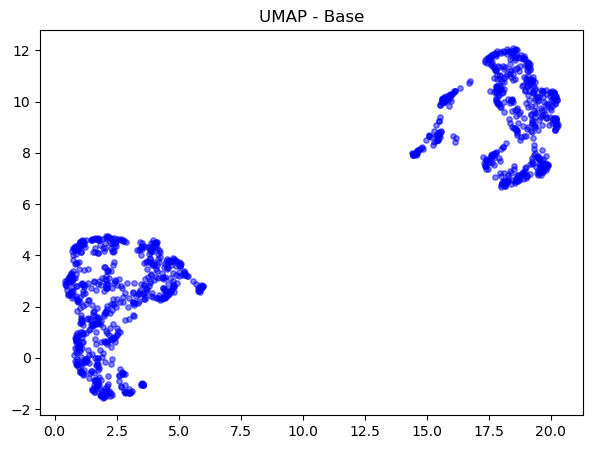

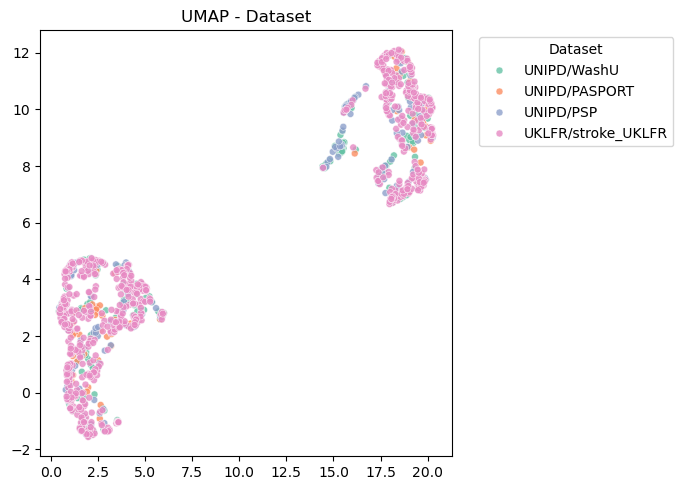

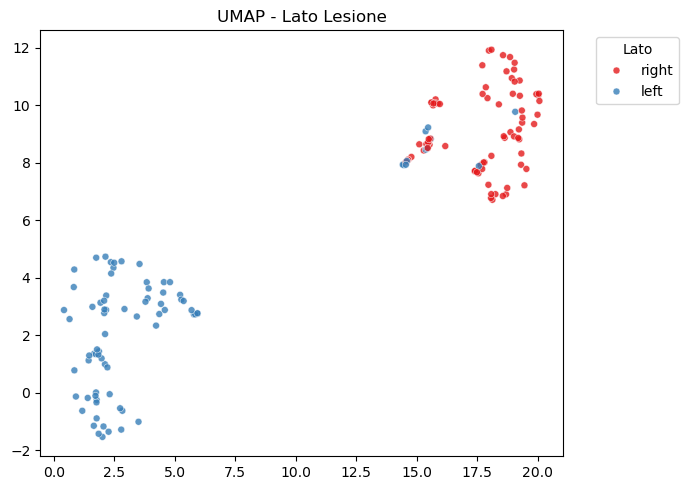

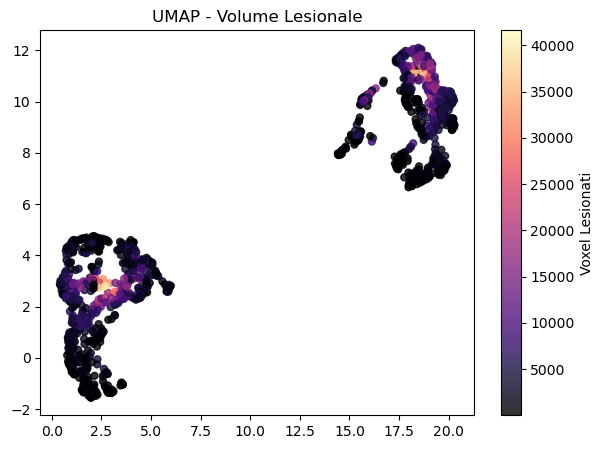

In [15]:
# --- UMAP ---
n_neighbors = 15
n_components = 2
min_dist = 0.1
random_state = 42

reducer_umap = umap.UMAP(
    n_neighbors=n_neighbors,
    n_components=n_components,
    metric="precomputed" if metric in ["jaccard", "dice"] else metric,
    n_epochs=1000,
    learning_rate=1.0,
    init='spectral',
    min_dist=min_dist,
    spread=1.0,
    low_memory=False,
    set_op_mix_ratio=1.0,
    local_connectivity=1,
    repulsion_strength=1.0,
    negative_sample_rate=5,
    transform_queue_size=4.0,
    random_state=random_state
)

print("Fit UMAP...")
embedding_umap = reducer_umap.fit_transform(X_dist)

# Plot UMAP separati per visibilità
plt.figure(figsize=(10, 8))
plt.scatter(embedding_umap[:, 0], embedding_umap[:, 1], s=15, alpha=0.5, c='blue')
plt.title('UMAP - Base')
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_umap[:, 0], y=embedding_umap[:, 1], hue=metadata['dataset_x'], palette='Set2', s=25, alpha=0.8)
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP - Dataset')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_umap[:, 0], y=embedding_umap[:, 1], hue=metadata['lesion_side'], palette='Set1', s=25, alpha=0.8)
plt.legend(title='Lato', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP - Lato Lesione')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x=embedding_umap[:, 0], y=embedding_umap[:, 1], c=metadata['volume_voxel'], cmap='magma', s=25, alpha=0.8)
plt.title('UMAP - Volume Lesionale')
plt.colorbar(scatter, label='Voxel Lesionati')
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x=embedding_umap[:, 0], y=embedding_umap[:, 1], c=metadata['NIHSS'], cmap='viridis', s=25, alpha=0.8)
plt.title('UMAP - Severità NIHSS')
plt.colorbar(scatter, label='NIHSS Score')
plt.show()

In [ ]:
# --- t-SNE ---
perplexity = 30
random_state = 42

reducer_tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    metric="precomputed" if metric in ["jaccard", "dice"] else metric,
    init='pca' if metric not in ["jaccard", "dice"] else 'random',
    learning_rate='auto',
    random_state=random_state
)

print("Fit t-SNE...")
embedding_tsne = reducer_tsne.fit_transform(X_dist)

# Plot t-SNE separati per visibilità
plt.figure(figsize=(10, 8))
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=15, alpha=0.5, c='green')
plt.title('t-SNE - Base')
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_tsne[:, 0], y=embedding_tsne[:, 1], hue=metadata['dataset_x'], palette='Set2', s=25, alpha=0.8)
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE - Dataset')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_tsne[:, 0], y=embedding_tsne[:, 1], hue=metadata['lesion_side'], palette='Set1', s=25, alpha=0.8)
plt.legend(title='Lato', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE - Lato Lesione')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x=embedding_tsne[:, 0], y=embedding_tsne[:, 1], c=metadata['volume_voxel'], cmap='magma', s=25, alpha=0.8)
plt.title('t-SNE - Volume Lesionale')
plt.colorbar(scatter, label='Voxel Lesionati')
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x=embedding_tsne[:, 0], y=embedding_tsne[:, 1], c=metadata['NIHSS'], cmap='viridis', s=25, alpha=0.8)
plt.title('t-SNE - Severità NIHSS')
plt.colorbar(scatter, label='NIHSS Score')
plt.show()

Scegli quale embedding usare per i clustering successivi:

In [8]:
# Scegli l'embedding (UMAP o t-SNE)
embedding_da_usare = embedding_umap
# embedding_da_usare = embedding_tsne

print(f"Embedding selezionato con shape: {embedding_da_usare.shape}")

Embedding selezionato con shape: (1150, 2)


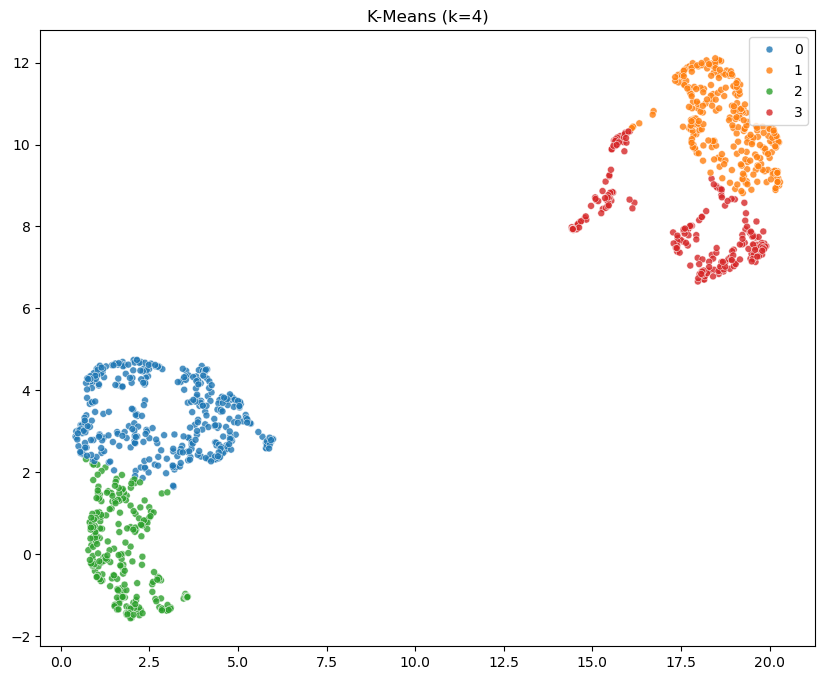

In [ ]:
# --- KMeans ---
k_kmeans = 4
kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(embedding_da_usare)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_kmeans, palette='tab10', legend='full', s=25, alpha=0.8)
plt.title(f'K-Means (k={k_kmeans})')
plt.show()

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


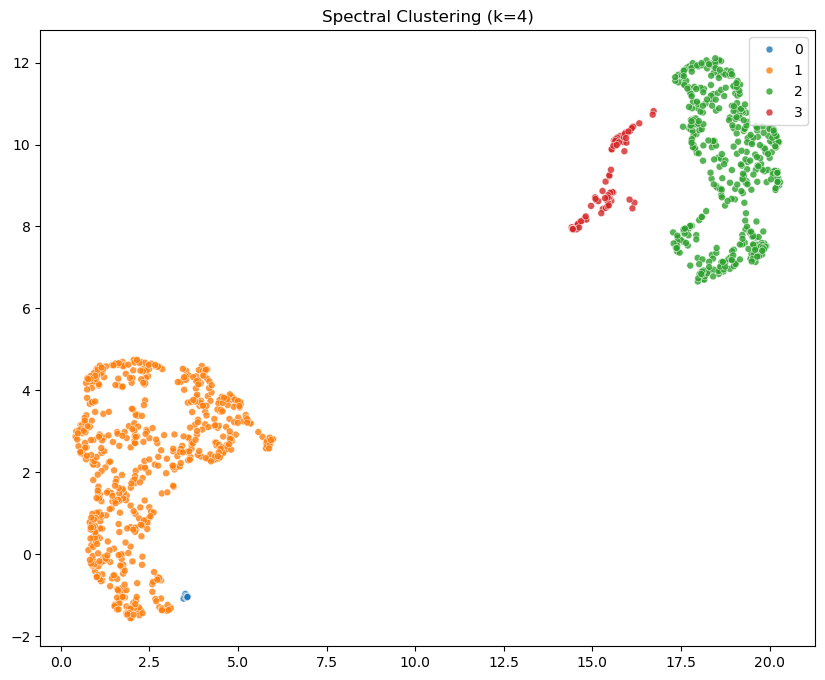

In [ ]:
# --- Spectral Clustering ---
k_spectral = 4
spectral = SpectralClustering(n_clusters=k_spectral, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(embedding_da_usare)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_spectral, palette='tab10', legend='full', s=25, alpha=0.8)
plt.title(f'Spectral Clustering (k={k_spectral})')
plt.show()

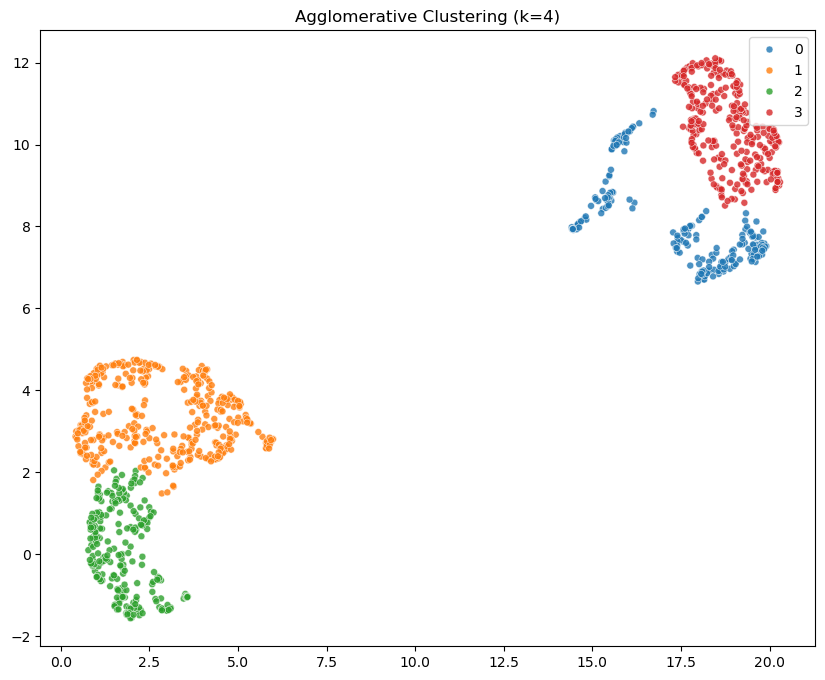

In [ ]:
# --- Agglomerative Clustering ---
k_agglomerative = 4
agglomerative = AgglomerativeClustering(n_clusters=k_agglomerative)
labels_agglomerative = agglomerative.fit_predict(embedding_da_usare)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_agglomerative, palette='tab10', legend='full', s=25, alpha=0.8)
plt.title(f'Agglomerative Clustering (k={k_agglomerative})')
plt.show()